In [7]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Drive
from google.colab import drive

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [8]:
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
file_path = "/content/drive/MyDrive/load_data.csv"

df = pd.read_csv(file_path)

In [10]:
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [11]:
print("Dataset Shape :", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

Dataset Shape : (35041, 9)

Column Names
Index(['Date_Time', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'Load_Type'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  object 
 1   Usage_kWh                             33482 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  34165 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  33885 non-null  float64
 4   CO2(tCO2)                             34586 non-null  float64
 5   Lagging_Current_Power_Factor          34691 non-null  float64
 6   Leading_Current_Power_Factor       

In [12]:
df.isnull().sum()

,0
Date_Time,0
Usage_kWh,1559
Lagging_Current_Reactive.Power_kVarh,876
Leading_Current_Reactive_Power_kVarh,1156
CO2(tCO2),455
Lagging_Current_Power_Factor,350
Leading_Current_Power_Factor,1471
NSM,455
Load_Type,0


In [13]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,33482.000000,34165.000000,33885.000000,34586.000000,34691.000000,33570.000000,34586.000000
mean,30.873061,14.704573,4.386097,0.012947,90.740871,94.926552,48013.664032
std,41.415015,20.342721,9.090181,0.019726,39.745395,49.826872,34046.492333
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.310000,2.340000,0.000000,0.000000,66.295000,99.800000,22500.000000
50%,5.290000,5.180000,0.000000,0.000000,90.080000,100.000000,45000.000000
75%,53.560000,23.510000,2.298558,0.020000,100.000000,100.000000,68400.000000
max,435.019069,262.630718,78.809000,0.188166,299.996814,299.969494,248821.810465


In [16]:
# Convert Date_Time to datetime format (DD-MM-YYYY HH:MM)
df["Date_Time"] = pd.to_datetime(
    df["Date_Time"],
    dayfirst=True
)

# Check datatype
print(df["Date_Time"].dtype)

# Display first few rows
df.head()

datetime64[ns]


,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,2018-01-01 01:15:00,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


In [17]:
# Extract useful time features

df["Year"] = df["Date_Time"].dt.year
df["Month"] = df["Date_Time"].dt.month
df["Day"] = df["Date_Time"].dt.day
df["Hour"] = df["Date_Time"].dt.hour
df["Minute"] = df["Date_Time"].dt.minute
df["DayOfWeek"] = df["Date_Time"].dt.dayofweek

# Weekend flag
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,2018-01-01 00:15:00,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load,2018,1,1,0,15,0,0
1,2018-01-01 00:30:00,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load,2018,1,1,0,30,0,0
2,2018-01-01 00:45:00,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load,2018,1,1,0,45,0,0
3,2018-01-01 01:00:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load,2018,1,1,1,0,0,0
4,2018-01-01 01:15:00,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load,2018,1,1,1,15,0,0


In [18]:
df.drop("Date_Time", axis=1, inplace=True)

df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load,2018,1,1,0,15,0,0
1,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load,2018,1,1,0,30,0,0
2,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load,2018,1,1,0,45,0,0
3,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load,2018,1,1,1,0,0,0
4,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load,2018,1,1,1,15,0,0


In [19]:
print(df["Month"].unique())

print(df["Month"].value_counts().sort_index())

[ 1  2  3  4  5  6  7  8  9 10 11 12]
Month
1     2976
2     2688
3     2976
4     2880
5     2976
6     2880
7     2976
8     2976
9     2880
10    2976
11    2880
12    2977
Name: count, dtype: int64


In [20]:
train = df[df["Month"] < 12]

test = df[df["Month"] == 12]

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

Training Shape : (32064, 15)
Testing Shape  : (2977, 15)


In [21]:
X_train = train.drop("Load_Type", axis=1)
y_train = train["Load_Type"]

X_test = test.drop("Load_Type", axis=1)
y_test = test["Load_Type"]

print(X_train.shape)
print(X_test.shape)

(32064, 14)
(2977, 14)


In [22]:
# Encode the target labels

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

print("Classes:", encoder.classes_)

Classes: ['Light_Load' 'Maximum_Load' 'Medium_Load']


In [23]:
print("Missing Values in Training Data:")
print(X_train.isnull().sum())

print("\nMissing Values in Testing Data:")
print(X_test.isnull().sum())

Missing Values in Training Data:
Usage_kWh                               1395
Lagging_Current_Reactive.Power_kVarh     795
Leading_Current_Reactive_Power_kVarh    1057
CO2(tCO2)                                418
Lagging_Current_Power_Factor             323
Leading_Current_Power_Factor            1352
NSM                                      404
Year                                       0
Month                                      0
Day                                        0
Hour                                       0
Minute                                     0
DayOfWeek                                  0
IsWeekend                                  0
dtype: int64

Missing Values in Testing Data:
Usage_kWh                               164
Lagging_Current_Reactive.Power_kVarh     81
Leading_Current_Reactive_Power_kVarh     99
CO2(tCO2)                                37
Lagging_Current_Power_Factor             27
Leading_Current_Power_Factor            119
NSM                        

In [24]:
numeric_features = X_train.columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [25]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

In [26]:
rf_model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [27]:
rf_prediction = rf_model.predict(X_test)

print(rf_prediction[:10])

[0 0 0 0 0 0 0 0 0 0]


In [28]:
accuracy = accuracy_score(y_test, rf_prediction)

print("Accuracy :", accuracy)

Accuracy : 0.9082969432314411


In [29]:
print(classification_report(
    y_test,
    rf_prediction,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

  Light_Load       0.99      0.92      0.95      1745
Maximum_Load       0.91      0.79      0.85       528
 Medium_Load       0.76      0.97      0.85       704

    accuracy                           0.91      2977
   macro avg       0.89      0.89      0.88      2977
weighted avg       0.92      0.91      0.91      2977



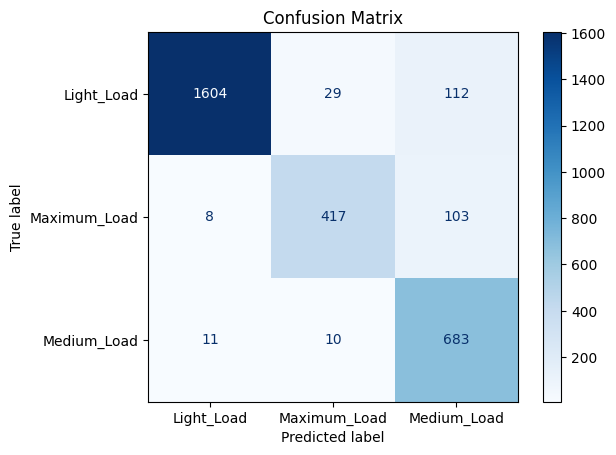

In [30]:
cm = confusion_matrix(y_test, rf_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.named_steps["classifier"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,Hour,0.249826
6,NSM,0.221324
0,Usage_kWh,0.105049
8,Month,0.098128
3,CO2(tCO2),0.071471
4,Lagging_Current_Power_Factor,0.062426
1,Lagging_Current_Reactive.Power_kVarh,0.047075
2,Leading_Current_Reactive_Power_kVarh,0.030741
12,DayOfWeek,0.030553
5,Leading_Current_Power_Factor,0.029619


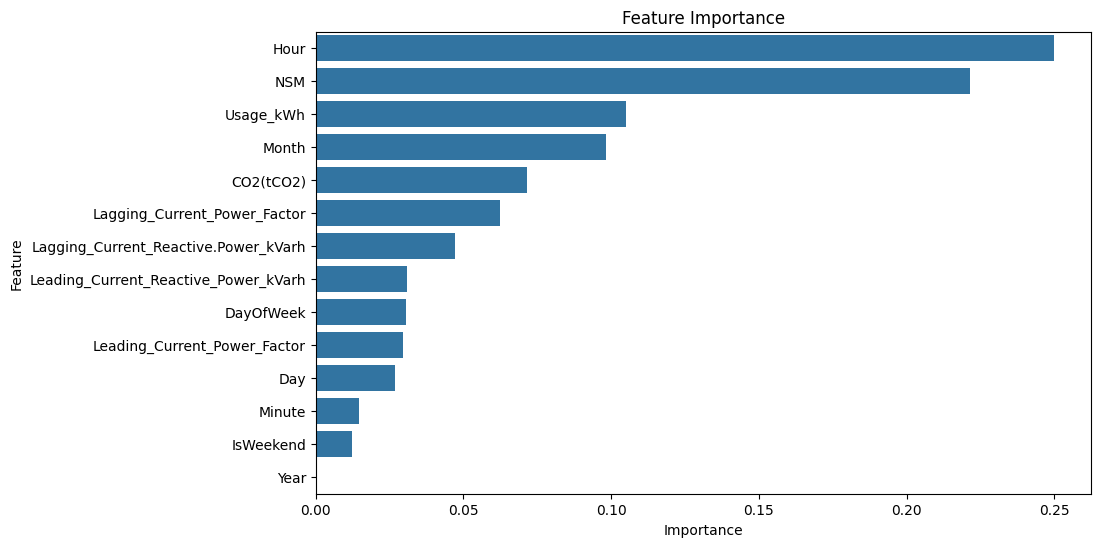

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [33]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

gb_model.fit(X_train, y_train)

gb_prediction = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_prediction))

Gradient Boosting Accuracy: 0.8827678871346993


In [34]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            objective="multi:softmax",
            num_class=3,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_prediction))

XGBoost Accuracy: 0.918374202216997


In [35]:
print(classification_report(
    y_test,
    xgb_prediction,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

  Light_Load       1.00      0.87      0.93      1745
Maximum_Load       0.84      0.97      0.90       528
 Medium_Load       0.83      0.99      0.90       704

    accuracy                           0.92      2977
   macro avg       0.89      0.95      0.91      2977
weighted avg       0.93      0.92      0.92      2977



In [36]:
tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.65999251 0.95003743 0.94723054 0.92009731 0.82204341]

Average Accuracy:
0.8598802395209582


In [38]:
# Create a comparison table

results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_prediction),
        accuracy_score(y_test, gb_prediction),
        accuracy_score(y_test, xgb_prediction)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,XGBoost,0.918374
0,Random Forest,0.908297
1,Gradient Boosting,0.882768


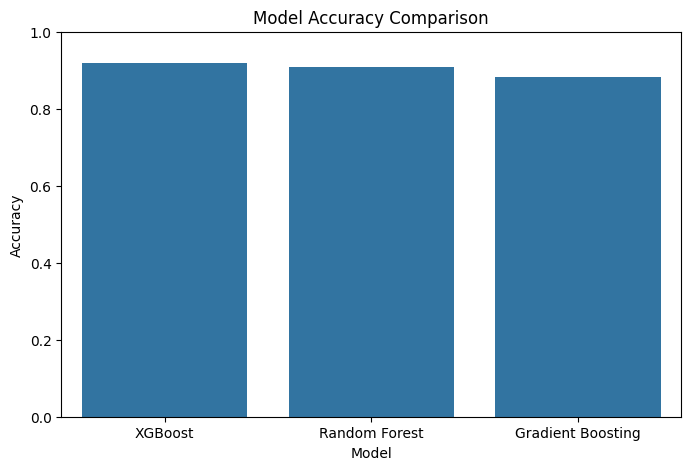

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

In [40]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Load Type :", encoder.inverse_transform(prediction))

Predicted Load Type : ['Light_Load']


In [41]:
import joblib

joblib.dump(rf_model, "Power_Load_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [42]:
loaded_model = joblib.load("Power_Load_Model.pkl")

prediction = loaded_model.predict(sample)

print("Prediction:", encoder.inverse_transform(prediction))

Prediction: ['Light_Load']


In [43]:
# Conclusion

In this project, a machine learning model was developed to predict the Load Type of a power system using historical energy consumption data.

The dataset was preprocessed by handling missing values, extracting useful date-time features, and scaling numerical attributes. A time-based validation strategy was adopted by using the last month (December) as the test dataset to evaluate the model on unseen future data.

Three classification algorithms were implemented:
- Random Forest
- Gradient Boosting
- XGBoost

The models were evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix. Cross-validation was also performed using TimeSeriesSplit to assess model robustness.

Among the evaluated models, the one with the highest accuracy can be selected as the final model for predicting future load categories such as Light_Load, Medium_Load, and Maximum_Load.

SyntaxError: invalid syntax (1413080588.py, line 3)